In [12]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from scipy.signal import detrend

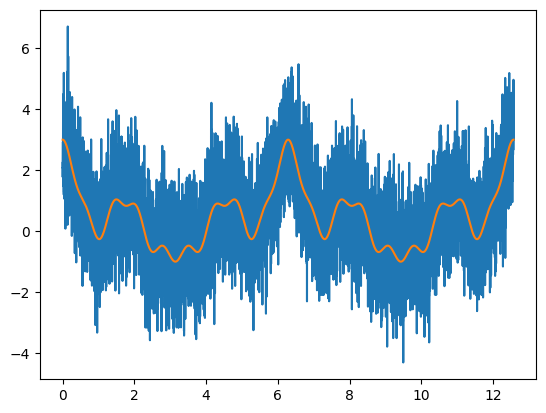

In [2]:
N = 10001
time = np.linspace(0,4*np.pi,N)

signal = np.zeros(N)

for j in range(1,4):
  signal += np.cos(j*time)**j

noisysignal = signal + np.random.randn(N)

plt.plot(time,noisysignal, time,signal)
plt.show()

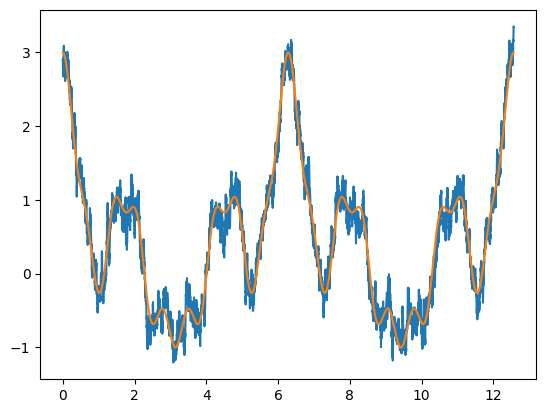

In [3]:
# Mean Smoothing Filter
filtered_signal = copy.deepcopy(noisysignal)

k = 15

for t in range(N):
  lower_bound = np.max((0,t-k))
  upper_bound = np.min((N,t+k))
  filtered_signal[t] = np.mean(noisysignal[lower_bound:upper_bound])

plt.plot(time,filtered_signal, time,signal)
plt.show()

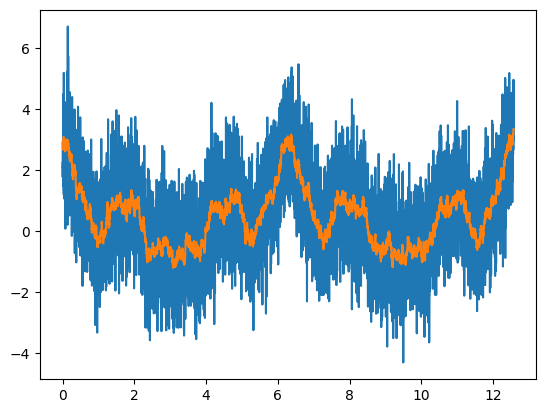

In [4]:
plt.plot(time, noisysignal, time, filtered_signal)

In [5]:
def mean_smooth(signalIn, k):
  filtered_signal = copy.deepcopy(signalIn)

  for t in range(N):
    filtered_signal[t] = np.mean(noisysignal[np.max((0,t-k)):np.min((N,t+k))])
  return filtered_signal

k_values = np.arange(5, 41)
signal_corrs = []


for k_index in k_values:
  # filter the signal
  f_signal = mean_smooth(noisysignal, k_index)

  # compute the correlation signal and original
  signal_corrs.append(np.corrcoef(f_signal, signal)[0, 1])

In [6]:
signal_corrs

[np.float64(0.9507011816316935),
 np.float64(0.9585233800701377),
 np.float64(0.9642705501157774),
 np.float64(0.9685577104601916),
 np.float64(0.9718355347940519),
 np.float64(0.9744219285805895),
 np.float64(0.9765576902818812),
 np.float64(0.9783619267534052),
 np.float64(0.9799263531805531),
 np.float64(0.9812513310710029),
 np.float64(0.9823824067677909),
 np.float64(0.9833013279107563),
 np.float64(0.9841098942219206),
 np.float64(0.9848314591120815),
 np.float64(0.9854901462216877),
 np.float64(0.9861159423679753),
 np.float64(0.9866735039201409),
 np.float64(0.987183561133652),
 np.float64(0.9876614347225141),
 np.float64(0.9881059158169369),
 np.float64(0.9885215577602532),
 np.float64(0.9889137444209919),
 np.float64(0.9892706476146068),
 np.float64(0.989585533833953),
 np.float64(0.989892865530032),
 np.float64(0.9901926458992298),
 np.float64(0.9904802744778414),
 np.float64(0.9907521258437854),
 np.float64(0.9910044940862247),
 np.float64(0.9912468289302867),
 np.float64(0

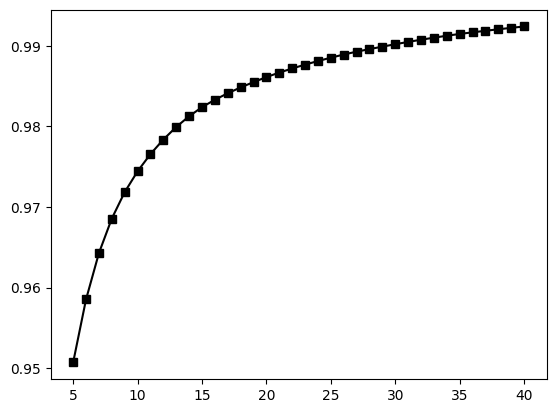

In [7]:
plt.plot(k_values, signal_corrs, 'ks-')

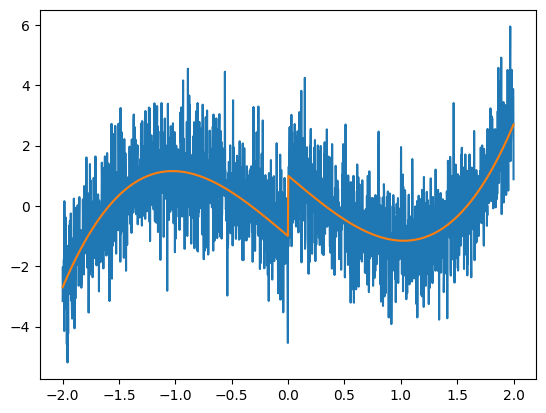

In [14]:
# Smooth via Gaussian Convoltion
# create signal

srate = 512
time = np.arange(-2, 2 + 1 / srate, 1 / srate)
points = len(time)

signal = detrend(time**3 + np.sign(time))
noisysignal = signal + np.random.randn(points) * 1.1

plt.plot(time, noisysignal, time, signal)

Text(0.5, 1.0, 'n=21, s=0.005')

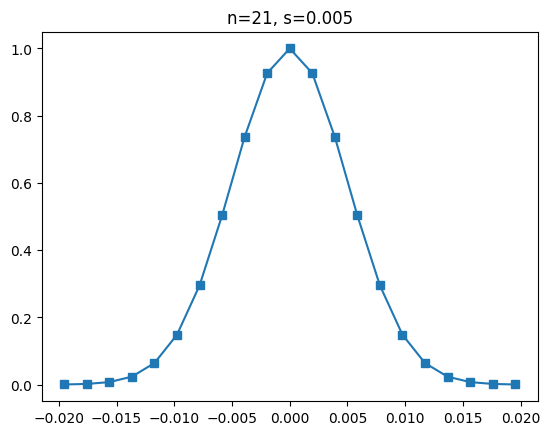

In [17]:
# Create the Gaussian
k = 10
x = np.arange(-k, k + 1) / srate
s = 0.005

gkern = np.exp(-x**2 / (2 * s**2))

plt.plot(x, gkern, 's-')
plt.title('n=%s, s=%g'%(2 * k + 1, s))

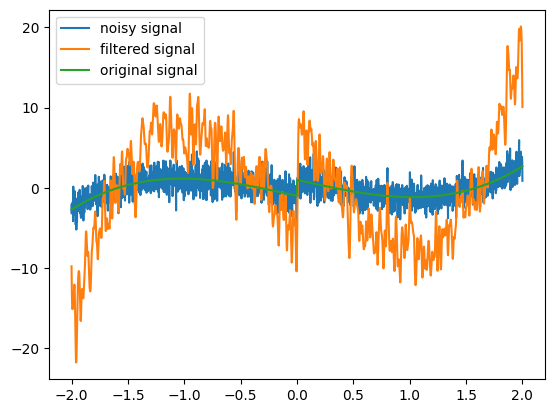

In [19]:
filtered_signal = np.convolve(noisysignal, gkern, mode='same')

plt.plot(time, noisysignal, time, filtered_signal, time, signal)
plt.legend(['noisy signal', 'filtered signal', 'original signal'])
plt.show()